# Phase 3: Exploratory Data Analysis
---
**Purpose:** Visual and descriptive exploration of dengue–rainfall patterns to motivate the modelling strategy. The analysis documents distributional characteristics (overdispersion, zero-inflation, skewness), temporal structure (seasonality, inter-annual variation), and preliminary cross-correlation between rainfall lags and dengue incidence.  
**Input:** `phase2b_output_with_lags.csv`  
**Output:** Descriptive statistics, EDA figures

## 3.1 Setup

In [8]:
!pip install -q pandas numpy matplotlib seaborn scipy

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from google.colab import files
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')

## 3.2 Load Data

In [9]:
print('Upload: phase2b_output_with_lags.csv')
uploaded = files.upload()
input_file = list(uploaded.keys())[0]
df = pd.read_csv(input_file)
print(f'Loaded: {len(df):,} records, {len(df.columns)} variables')
print(f'MOH areas: {sorted(df["MOH"].unique())}')
print(f'Study period: {df["Year"].min()}–{df["Year"].max()}')

Upload: phase2b_output_with_lags.csv


Saving phase2b_output_with_lags (10).csv to phase2b_output_with_lags (10).csv
Loaded: 520 records, 30 variables
MOH areas: ['Balangoda', 'Udawalawa']
Study period: 2020–2024


## 3.3 Descriptive Statistics

In [10]:
# Summary statistics by MOH area
print('  DESCRIPTIVE STATISTICS BY MOH AREA')

for moh in sorted(df['MOH'].unique()):
    sub = df[df['MOH']==moh]
    desc = sub[['Dengue_Cases', 'Weekly_Mean_Rainfall']].describe().round(3)
    desc.loc['variance'] = sub[['Dengue_Cases', 'Weekly_Mean_Rainfall']].var().round(3)
    desc.loc['skewness'] = sub[['Dengue_Cases', 'Weekly_Mean_Rainfall']].skew().round(3)
    print(f'\n{moh}:')
    print(desc)

    mean_d = sub['Dengue_Cases'].mean()
    var_d = sub['Dengue_Cases'].var()
    ratio = var_d / mean_d if mean_d > 0 else np.nan
    zero_pct = (sub['Dengue_Cases']==0).mean() * 100
    print(f'  Variance / Mean = {ratio:.3f} (>1 indicates overdispersion)')
    print(f'  Zero-case weeks = {zero_pct:.1f}%')

  DESCRIPTIVE STATISTICS BY MOH AREA

Balangoda:
          Dengue_Cases  Weekly_Mean_Rainfall
count          260.000               260.000
mean             2.392                 6.579
std              3.849                 7.653
min              0.000                 0.000
25%              0.000                 0.654
50%              1.000                 3.871
75%              3.000                 9.154
max             28.000                34.086
variance        14.818                58.562
skewness         3.369                 1.484
  Variance / Mean = 6.194 (>1 indicates overdispersion)
  Zero-case weeks = 36.5%

Udawalawa:
          Dengue_Cases  Weekly_Mean_Rainfall
count          260.000               260.000
mean             1.062                 4.169
std              1.725                 5.446
min              0.000                 0.000
25%              0.000                 0.221
50%              0.000                 1.807
75%              2.000                 5.707
ma

## 3.4 Weekly Time Series

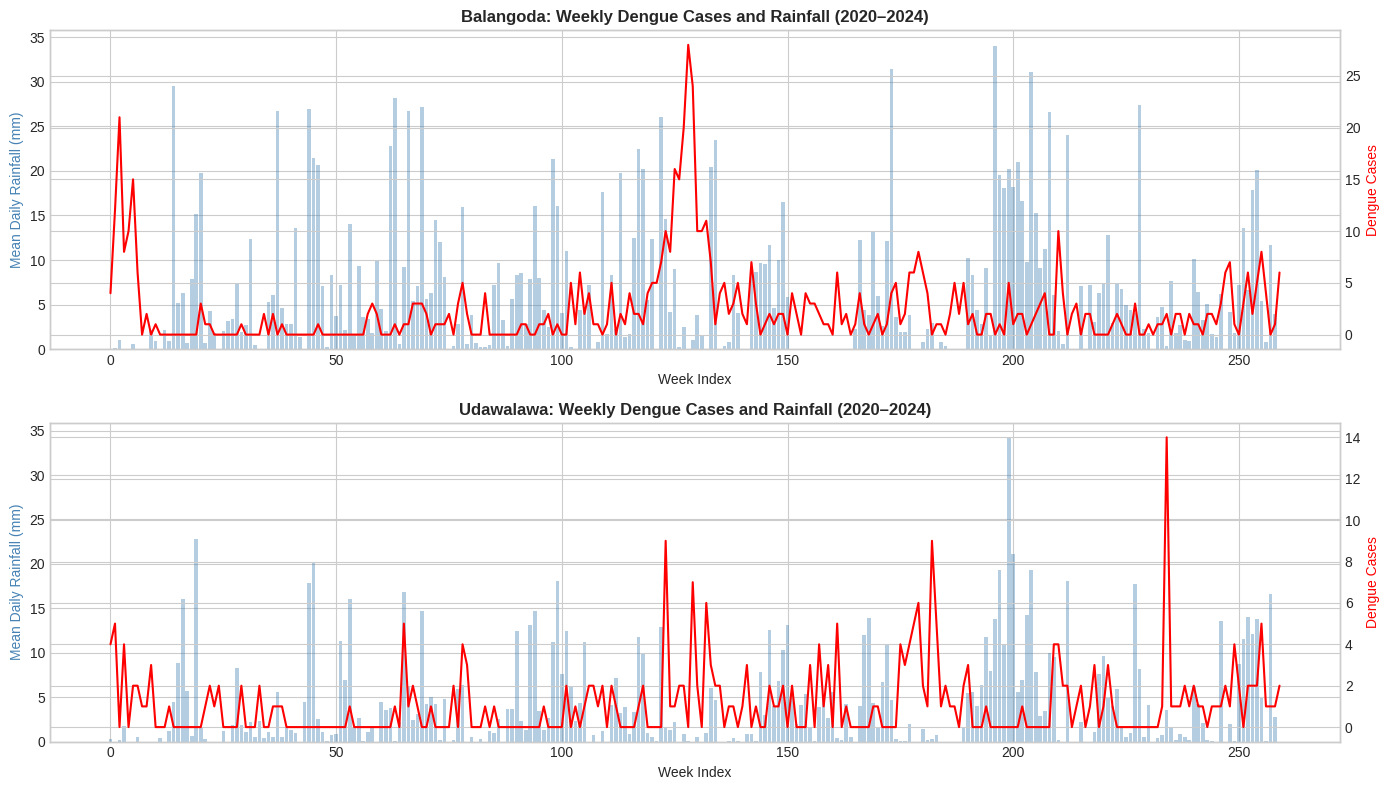

In [11]:
# Dual-axis time series: dengue (line) + rainfall (bars)
df_sorted = df.sort_values(['MOH','Year','Week']).reset_index(drop=True)
df_sorted['Time_Index'] = df_sorted.groupby('MOH').cumcount()

fig, axes = plt.subplots(2, 1, figsize=(14, 8))
for idx, moh in enumerate(sorted(df['MOH'].unique())):
    sub = df_sorted[df_sorted['MOH']==moh]
    ax1 = axes[idx]
    ax1.bar(sub['Time_Index'], sub['Weekly_Mean_Rainfall'],
            alpha=0.4, color='steelblue', label='Rainfall (mm/day)')
    ax1.set_ylabel('Mean Daily Rainfall (mm)', color='steelblue')
    ax1.set_xlabel('Week Index')
    ax2 = ax1.twinx()
    ax2.plot(sub['Time_Index'], sub['Dengue_Cases'],
             color='red', lw=1.5, label='Dengue Cases')
    ax2.set_ylabel('Dengue Cases', color='red')
    ax1.set_title(f'{moh}: Weekly Dengue Cases and Rainfall (2020–2024)', fontweight='bold')
plt.tight_layout()
plt.savefig('phase3_timeseries.png', dpi=300, bbox_inches='tight')
plt.show()

## 3.5 Dengue Distribution and Overdispersion

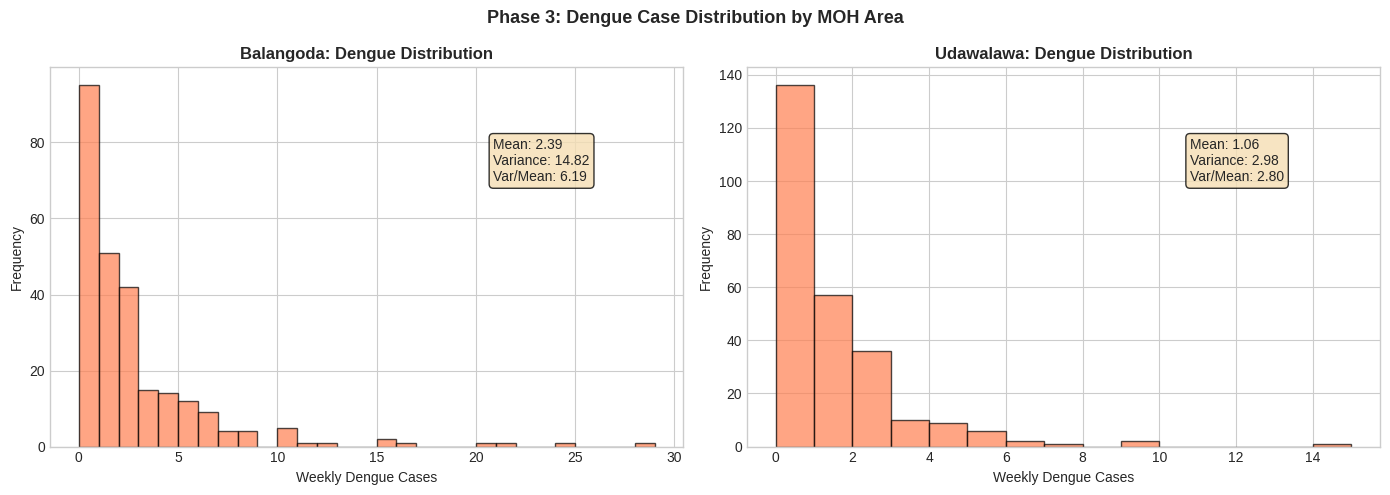

In [12]:
# Histograms with variance/mean annotation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Phase 3: Dengue Case Distribution by MOH Area', fontsize=13, fontweight='bold')

for idx, moh in enumerate(sorted(df['MOH'].unique())):
    sub = df[df['MOH']==moh]['Dengue_Cases']
    axes[idx].hist(sub, bins=range(0, int(sub.max())+2), alpha=0.7,
                   color='coral', edgecolor='black')
    axes[idx].set_xlabel('Weekly Dengue Cases')
    axes[idx].set_ylabel('Frequency')
    axes[idx].set_title(f'{moh}: Dengue Distribution', fontweight='bold')
    mean_v, var_v = sub.mean(), sub.var()
    axes[idx].annotate(
        f'Mean: {mean_v:.2f}\nVariance: {var_v:.2f}\nVar/Mean: {var_v/mean_v:.2f}',
        xy=(0.7, 0.7), xycoords='axes fraction',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8)
    )
plt.tight_layout()
plt.savefig('phase3_dengue_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

## 3.6 Seasonal Patterns

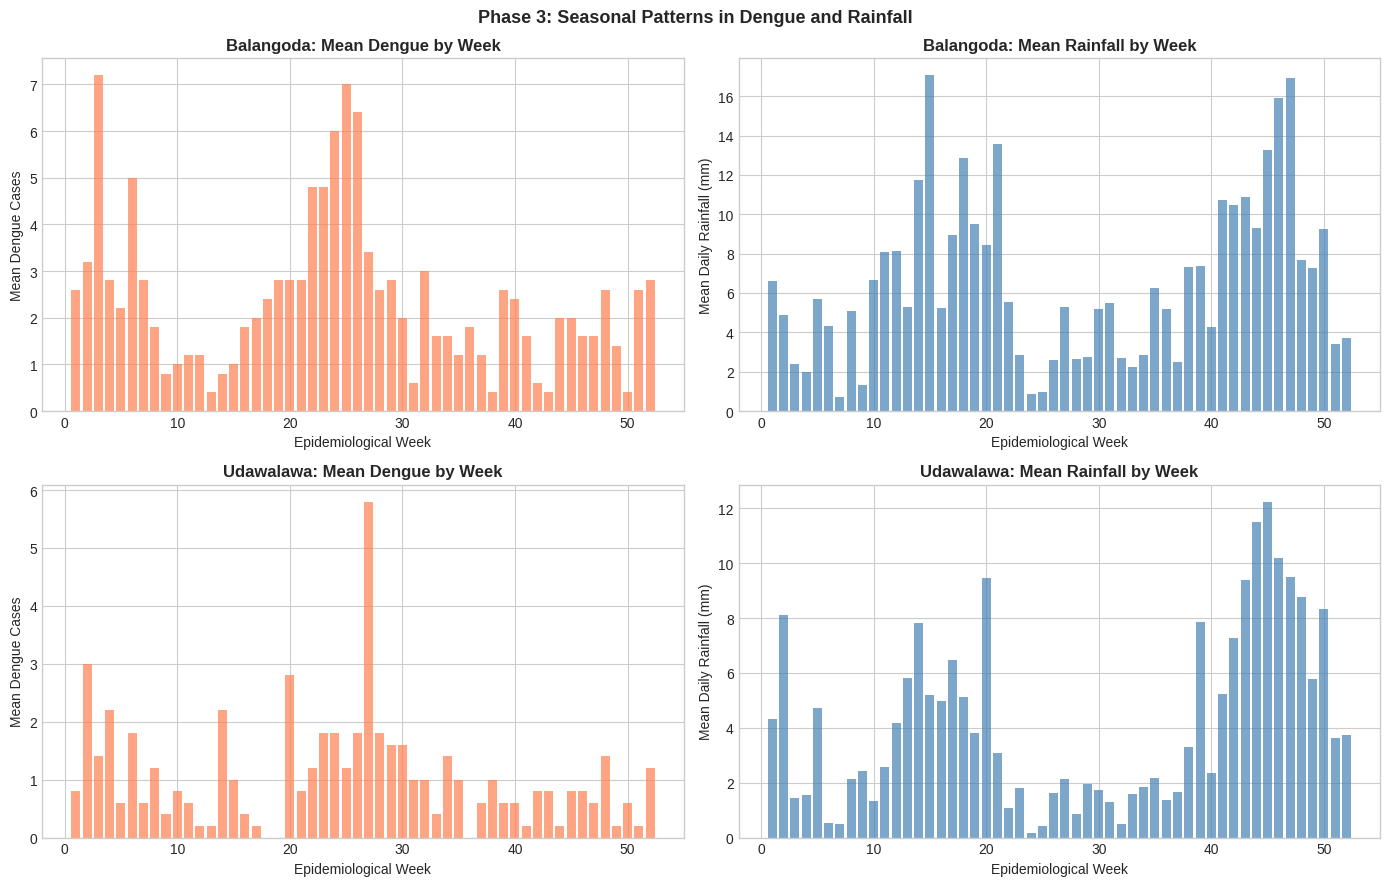

In [13]:
# Mean dengue and rainfall by epidemiological week
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Phase 3: Seasonal Patterns in Dengue and Rainfall', fontsize=13, fontweight='bold')

for idx, moh in enumerate(sorted(df['MOH'].unique())):
    sub = df[df['MOH']==moh]
    # Mean dengue by week
    axes[idx,0].bar(sub.groupby('Week')['Dengue_Cases'].mean().index,
                    sub.groupby('Week')['Dengue_Cases'].mean().values,
                    color='coral', alpha=0.7)
    axes[idx,0].set_title(f'{moh}: Mean Dengue by Week', fontweight='bold')
    axes[idx,0].set_ylabel('Mean Dengue Cases')
    axes[idx,0].set_xlabel('Epidemiological Week')
    # Mean rainfall by week
    axes[idx,1].bar(sub.groupby('Week')['Weekly_Mean_Rainfall'].mean().index,
                    sub.groupby('Week')['Weekly_Mean_Rainfall'].mean().values,
                    color='steelblue', alpha=0.7)
    axes[idx,1].set_title(f'{moh}: Mean Rainfall by Week', fontweight='bold')
    axes[idx,1].set_ylabel('Mean Daily Rainfall (mm)')
    axes[idx,1].set_xlabel('Epidemiological Week')
plt.tight_layout()
plt.savefig('phase3_seasonal_patterns.png', dpi=300, bbox_inches='tight')
plt.show()

## 3.7 Cross-Correlation: Rainfall Lags vs Dengue

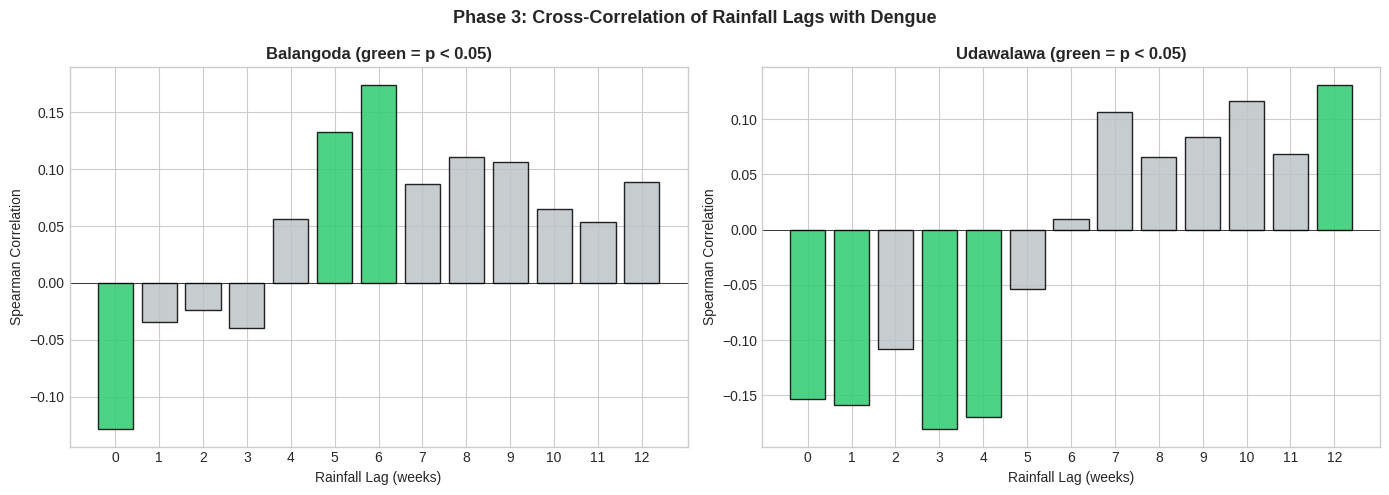

In [14]:
# Spearman cross-correlation at lags 0–12
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Phase 3: Cross-Correlation of Rainfall Lags with Dengue', fontsize=13, fontweight='bold')

for idx, moh in enumerate(sorted(df['MOH'].unique())):
    sub = df[df['MOH']==moh].dropna(subset=[f'Rainfall_Lag{i}' for i in range(1,13)])
    correlations, p_values = [], []
    # Lag 0 (contemporaneous)
    r0, p0 = stats.spearmanr(sub['Weekly_Mean_Rainfall'], sub['Dengue_Cases'])
    correlations.append(r0); p_values.append(p0)
    # Lags 1–12
    for lag in range(1, 13):
        r, p = stats.spearmanr(sub[f'Rainfall_Lag{lag}'], sub['Dengue_Cases'])
        correlations.append(r); p_values.append(p)

    colors = ['#2ECC71' if p < 0.05 else '#BDC3C7' for p in p_values]
    axes[idx].bar(range(13), correlations, color=colors, alpha=0.85, edgecolor='black')
    axes[idx].axhline(0, color='black', lw=0.5)
    axes[idx].set_xlabel('Rainfall Lag (weeks)')
    axes[idx].set_ylabel('Spearman Correlation')
    axes[idx].set_title(f'{moh} (green = p < 0.05)', fontweight='bold')
    axes[idx].set_xticks(range(13))
plt.tight_layout()
plt.savefig('phase3_cross_correlation.png', dpi=300, bbox_inches='tight')
plt.show()

## 3.8 Inter-Annual Variation

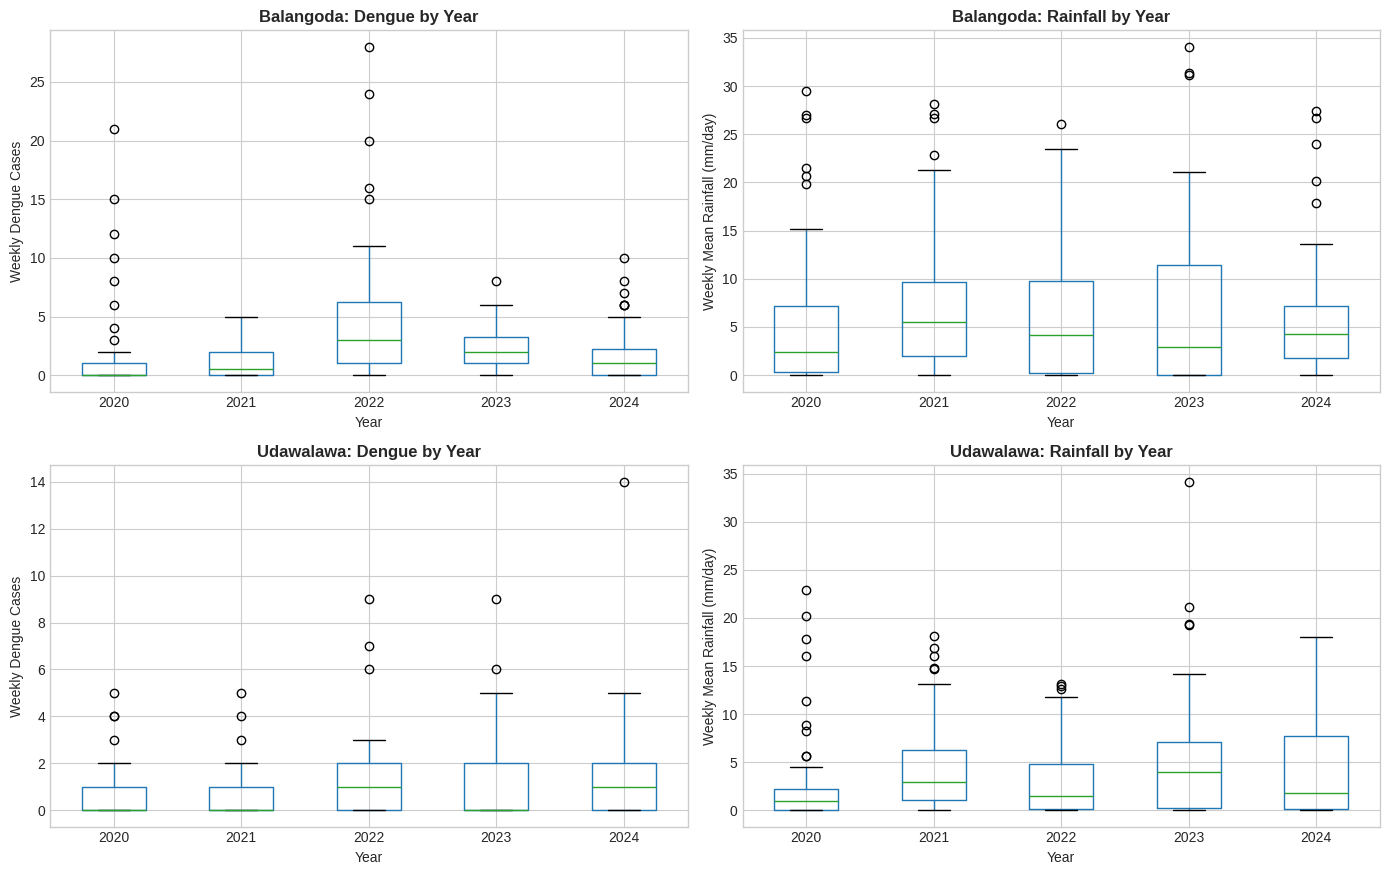

In [15]:
# Boxplots by year to show inter-annual variation
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Phase 3: Inter-Annual Variation (2020–2024)', fontsize=13, fontweight='bold')

for idx, moh in enumerate(sorted(df['MOH'].unique())):
    sub = df[df['MOH']==moh]
    sub.boxplot(column='Dengue_Cases', by='Year', ax=axes[idx,0])
    axes[idx,0].set_title(f'{moh}: Dengue by Year', fontweight='bold')
    axes[idx,0].set_ylabel('Weekly Dengue Cases')
    sub.boxplot(column='Weekly_Mean_Rainfall', by='Year', ax=axes[idx,1])
    axes[idx,1].set_title(f'{moh}: Rainfall by Year', fontweight='bold')
    axes[idx,1].set_ylabel('Weekly Mean Rainfall (mm/day)')
plt.suptitle('')  # remove auto title from boxplot
plt.tight_layout()
plt.savefig('phase3_interannual.png', dpi=300, bbox_inches='tight')
plt.show()

## 3.9 EDA Summary

In [16]:
# Synthesise key findings from the EDA
print('  EDA SUMMARY ')
for moh in sorted(df['MOH'].unique()):
    sub = df[df['MOH']==moh]
    mean_d = sub['Dengue_Cases'].mean()
    var_d = sub['Dengue_Cases'].var()
    max_d = sub['Dengue_Cases'].max()
    zero_pct = (sub['Dengue_Cases']==0).mean() * 100
    mean_r = sub['Weekly_Mean_Rainfall'].mean()
    max_r = sub['Weekly_Mean_Rainfall'].max()
    print(f'\n{moh}:')
    print(f'  Dengue : mean={mean_d:.2f}, var={var_d:.2f}, max={max_d}, zero-weeks={zero_pct:.1f}%')
    print(f'  Rain   : mean={mean_r:.2f} mm/day, max={max_r:.2f} mm/day')
    print(f'  Overdispersion ratio = {var_d/mean_d:.2f} → Negative Binomial justified')


  EDA SUMMARY 

Balangoda:
  Dengue : mean=2.39, var=14.82, max=28, zero-weeks=36.5%
  Rain   : mean=6.58 mm/day, max=34.09 mm/day
  Overdispersion ratio = 6.19 → Negative Binomial justified

Udawalawa:
  Dengue : mean=1.06, var=2.98, max=14, zero-weeks=52.3%
  Rain   : mean=4.17 mm/day, max=34.17 mm/day
  Overdispersion ratio = 2.80 → Negative Binomial justified
